# Lecture 04 — Suspicious transaction alerts

**Module:** OMC9000UK7 · Principles and Applications of Artificial Intelligence and Machine Learning  
**Programme:** MSc AI and Machine Learning · Gulf College  
**Lecture:** 04 — Introduction to Machine Learning and Data Mining  
**Topic:** Anomaly detection · **Learning outcome emphasis:** MLO1 and MLO3 (with MLO4 preparation through technique selection)

## Learning objective
Flag unusual synthetic payment patterns using Isolation Forest and evaluate against withheld simulation truth.

## Practical problem
The anomaly detector reviews payment amount, geographic distance, time and short-term transaction frequency.

## Dataset and transparency
The file **`dataset.csv`** was simulated for teaching. It is not collected from real people, businesses, medical systems or physical devices. Names/values are illustrative; models must not be deployed or used for real eligibility, employment, financial, clinical or safety decisions. A fixed random seed makes the example reproducible.

**How to run:** keep this notebook and `dataset.csv` in the same folder, then run all cells from top to bottom. If needed, install the packages listed in the collection’s `requirements.txt`.

**Assumptions:** Unusual does not mean fraudulent; invented outliers are easier than genuine fraud and must not be treated as factual risk profiles.

## 1. Load the dataset and understand the variables
Always inspect several rows, column names, types, and possible missing values before choosing a model.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (7.2, 4.5), 'axes.grid': True, 'grid.alpha': .22})
DATA_FILE = Path('dataset.csv')
assert DATA_FILE.exists(), 'Place dataset.csv next to the notebook.'
df = pd.read_csv(DATA_FILE)
print(f'Dataset: {len(df):,} rows × {df.shape[1]} columns')
display(df.head())

Dataset: 850 rows × 5 columns


,amount_omr,distance_from_home_km,hour_of_day,transactions_last_hour,is_anomaly
0,75.6,21.3,9,5,0
1,1985.1,277.2,3,8,1
2,128.5,57.2,22,1,0
3,134.3,4.8,21,2,0
4,68.7,2.8,14,2,0


In [2]:
print('Columns:', df.columns.tolist())
print('Missing values per column:')
print(df.isna().sum().to_string())

Columns: ['amount_omr', 'distance_from_home_km', 'hour_of_day', 'transactions_last_hour', 'is_anomaly']
Missing values per column:
amount_omr                0
distance_from_home_km     0
hour_of_day               0
transactions_last_hour    0
is_anomaly                0


## 2. Explore typical versus unusual observations
The `is_anomaly` field was generated by the simulator as a **hidden evaluation label**. The unsupervised model must not fit on that field.

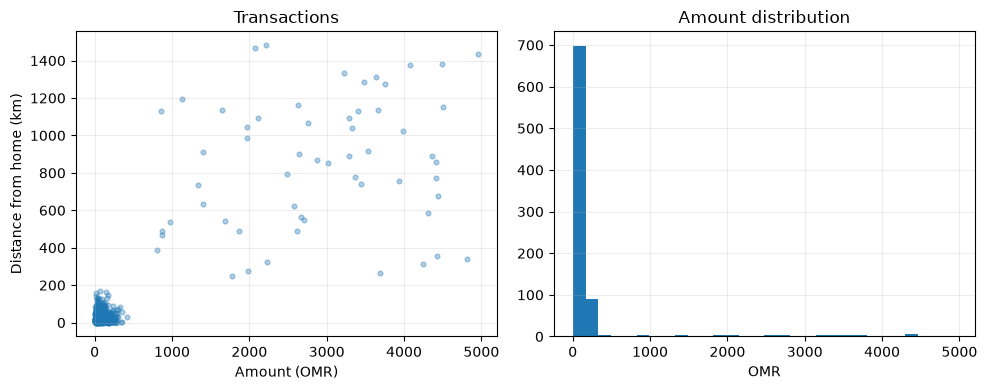

In [3]:
fig,ax=plt.subplots(1,2,figsize=(10,4))
ax[0].scatter(df['amount_omr'],df['distance_from_home_km'],s=12,alpha=.35)
ax[0].set(xlabel='Amount (OMR)',ylabel='Distance from home (km)',title='Transactions')
ax[1].hist(df['amount_omr'],bins=30);ax[1].set(title='Amount distribution',xlabel='OMR');plt.tight_layout();plt.show()

## 3. Fit an Isolation Forest
**Isolation Forest** isolates unusual points using random splits. Anomalies typically require fewer splits. `contamination` gives the expected fraction flagged, so choosing it affects false alarms.

In [4]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,precision_score,recall_score,classification_report,ConfusionMatrixDisplay
features=['amount_omr', 'distance_from_home_km', 'hour_of_day', 'transactions_last_hour']
X=df[features]
scaler=StandardScaler();X_scaled=scaler.fit_transform(X)
model=IsolationForest(n_estimators=120,contamination=0.07,random_state=42)
model.fit(X_scaled) # No is_anomaly labels!
df['anomaly_prediction']=(model.predict(X_scaled)==-1).astype(int)
print('Flagged:',int(df['anomaly_prediction'].sum()),'of',len(df))

Flagged: 60 of 850


## 4. Evaluate against the **simulation-only** ground truth
Because the simulator created known anomaly labels, we can illustrate accuracy, precision, recall and a confusion matrix. In authentic unsupervised anomaly detection, reliable ground truth often does not exist and these metrics are unavailable.

Accuracy: 0.996
Precision (anomaly): 0.95
Recall (anomaly): 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       793
           1       0.95      1.00      0.97        57

    accuracy                           1.00       850
   macro avg       0.97      1.00      0.99       850
weighted avg       1.00      1.00      1.00       850



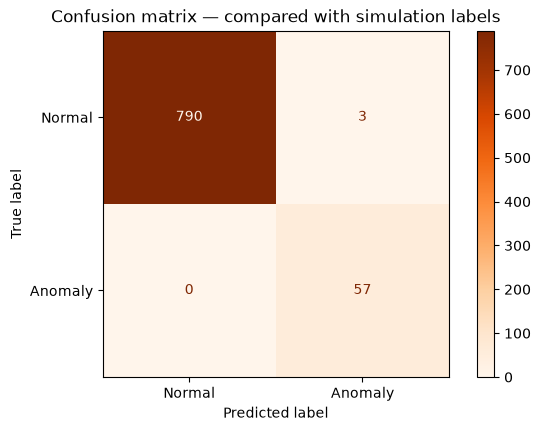

In [5]:
y_true=df['is_anomaly'];y_pred=df['anomaly_prediction']
print('Accuracy:',round(accuracy_score(y_true,y_pred),3))
print('Precision (anomaly):',round(precision_score(y_true,y_pred,zero_division=0),3))
print('Recall (anomaly):',round(recall_score(y_true,y_pred,zero_division=0),3))
print(classification_report(y_true,y_pred,zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_true,y_pred,display_labels=['Normal','Anomaly'],cmap='Oranges')
plt.title('Confusion matrix — compared with simulation labels');plt.grid(False);plt.show()

## 5. Show flagged anomalies and score new observations

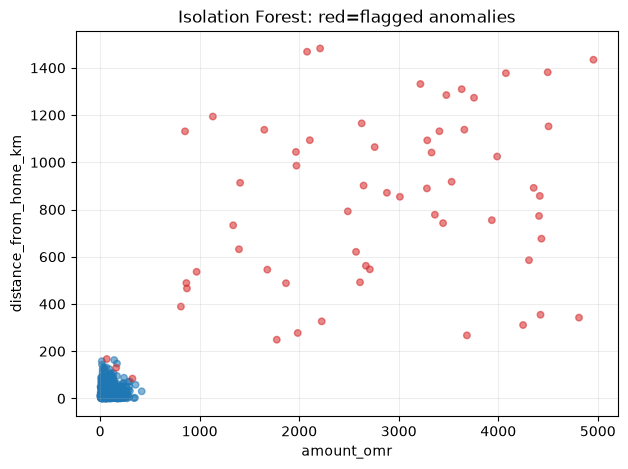

In [6]:
fig,ax=plt.subplots(figsize=(7,5))
colors=np.where(df['anomaly_prediction']==1,'tab:red','tab:blue')
ax.scatter(df[features[0]],df[features[1]],c=colors,alpha=.55,s=22)
ax.set(xlabel=features[0],ylabel=features[1],title='Isolation Forest: red=flagged anomalies');plt.show()

In [7]:
new=pd.DataFrame([{'amount_omr':55,'distance_from_home_km':8,'hour_of_day':13,'transactions_last_hour':2},{'amount_omr':2900,'distance_from_home_km':740,'hour_of_day':2,'transactions_last_hour':17}])
new['flagged']=(model.predict(scaler.transform(new[features]))==-1).astype(int)
display(new)

,amount_omr,distance_from_home_km,hour_of_day,transactions_last_hour,flagged
0,55,8,13,2,0
1,2900,740,2,17,1


## Student investigation and discussion
1. Why does low prevalence make precision difficult?
2. Why is an anomaly flag not proof of fraud?
3. How does increasing contamination change recall and false positives?

**Reflect:** What assumption makes this classroom dataset easier than the equivalent real-world problem?

## References and further learning
- Russell, S. J., & Norvig, P. (2021). *Artificial Intelligence: A Modern Approach* (4th ed.). Pearson.
- Mitchell, T. M. (1997). *Machine Learning*. McGraw-Hill.
- scikit-learn User Guide: https://scikit-learn.org/stable/user_guide.html
- Course connection: Lecture 04, OMC9000UK7, supervised/unsupervised learning, modelling workflow and evaluation.